# Чтение штрихкодов: демонстрация решения

Карим Гимадиев · Ozon CV, вариант 2. Выполняйте ячейки по порядку на CPU.

В Jupyter Notebook используются синтетические изображения и сквозной имитатор захвата и WCS. Инженерные расчёты и промышленная программа приёмки приведены в PDF репозитория.

In [1]:
from pathlib import Path
import os, sys, subprocess, json
root = Path.cwd()
if (root / "barcode_reader").is_dir():
    pass
elif (root.parent / "barcode_reader").is_dir():
    root = root.parent
else:
    root = root / "ozon-barcode-reader"
    if not root.exists():
        subprocess.run(["git", "clone", "--branch", "submission-v3", "https://github.com/gimacorp/ozon-barcode-reader.git", str(root)], check=True)
os.chdir(root)
sys.path.insert(0, str(root))
os.environ.setdefault("MPLCONFIGDIR", str(root / ".cache/matplotlib"))
print("Репозиторий:", root.name)


Репозиторий: ozon lab


## Зависимости

При отсутствии нужных пакетов ячейка устанавливает версии из requirements.txt. Для точного повторения отчётного прогона используйте Python 3.12 и все закреплённые версии.

In [2]:
from importlib.metadata import version, PackageNotFoundError
requirements = [line.strip().split("==") for line in (Path("requirements-core.txt").read_text()+Path("requirements-report.txt").read_text()+Path("requirements-test.txt").read_text()).splitlines() if "==" in line]
def matches(name, pinned):
    try:
        return version(name) == pinned
    except PackageNotFoundError:
        return False
if any(not matches(name, pinned) for name, pinned in requirements):
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
from barcode_reader.synthetic import label
from barcode_reader.decoder import decode


## 1. Настоящее декодирование

Отдельный генератор создаёт Code 128. ZXing-C++ получает изображение и возвращает содержимое и координаты.

Прочитанные значения: ['OZON000001']


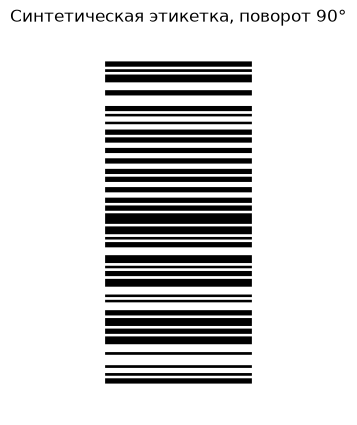

In [3]:
import numpy as np
import matplotlib.pyplot as plt
image = np.rot90(label("OZON000001", 3)).copy()
readings = decode(image)
print("Прочитанные значения:", [d.text for d in readings])
assert [d.text for d in readings] == ["OZON000001"]
plt.figure(figsize=(3, 5))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Синтетическая этикетка, поворот 90°")
plt.axis("off")
plt.show()


## 2. Геометрия и сроки

Параметры можно менять в configs/conveyor.json. Модель фокуса проверяет целую этикетку; контраст реальной оптики требует стендового испытания.

In [4]:
from barcode_reader.engineering import load_config, summarize
from barcode_reader.geometry import evaluate_label_focus
config = load_config()
values = summarize(config)
print("Пикселей на модуль сверху:", round(values["line_px_module_horizontal"], 2))
print("Бюджет обработки и доставки, мс:", round(values["remaining_processing_delivery_s"]*1000))
print("Проверка фокуса:", evaluate_label_focus(config))


Пикселей на модуль сверху: 3.86
Бюджет обработки и доставки, мс: 635
Проверка фокуса: {'required_frames': 1, 'aperture': 11.0, 'labels_per_phase': 972, 'phases': 21, 'min_whole_label_coverage': 1.0, 'geometric_dof_mm': 92.1015862379702, 'limitation': 'Дискретная номинальная геометрия. Не учитывает MTF, дифракцию, вибрацию и кривизну коробки.'}


## 3. Короткий эксперимент

Шесть коробок сохраняются отдельно от отчётной выборки. Полный опыт: 60 коробок, seed 20260909. Время зависит от среды выполнения.

In [5]:
from barcode_reader.benchmark import run
experiment = run(output="output/quick", boxes=6)
for m in experiment["metrics"]:
    if m["level"] == "all":
        print(m["method"], "полное множество:", round(m["exact_set_rate"]*100, 1), "%",
              "ложных значений:", m["false_values"], "p95, мс:", round(m["latency_p95_ms"], 1))


one_frame полное множество: 16.7 % ложных значений: 0 p95, мс: 34.2
three_frames полное множество: 66.7 % ложных значений: 0 p95, мс: 79.2
three_frames_enhanced полное множество: 66.7 % ложных значений: 0 p95, мс: 464.0
three_frames_diagonal полное множество: 66.7 % ложных значений: 0 p95, мс: 24.7


## 4. Пакет контроллеру и повторная доставка

Имитатор обрабатывает один message_id один раз. Поле complete_set_verified сохраняет неопределённость общего числа физических этикеток.

In [6]:
from barcode_reader.replay import run_replay
control = run_replay()
for box in control["boxes"]:
    print(box["box_id"], box["message"]["status"], box["message"]["codes"], box["retry_ack"]["receipt"])
assert all(box["message"]["status"] == "read" for box in control["boxes"])
assert control["stale_session_rejected"]
assert control["retained_assignments"] == 0


A read [{'format': 'Code 128', 'text': 'SHARED01', 'payload_hex': '5348415245443031', 'confirmations': 14, 'faces': ['bottom', 'front', 'left', 'rear', 'right', 'top']}] duplicate
B read [{'format': 'Code 128', 'text': 'SHARED01', 'payload_hex': '5348415245443031', 'confirmations': 14, 'faces': ['bottom', 'front', 'left', 'rear', 'right', 'top']}] duplicate


## 5. Автоматические проверки

Тесты охватывают декодирование, несколько символов, полосы, сроки, ID, повторные сообщения и геометрию.

In [7]:
result = subprocess.run([sys.executable, "-m", "pytest", "-q"], capture_output=True, text=True)
print(result.stdout)
if result.returncode:
    print(result.stderr)
result.check_returncode()


........................................................................ [ 60%]
...............................................                          [100%]
119 passed in 1.19s



## Практический следующий шаг

Для промышленного пилота сначала проверьте минимальный код на торцах при F/11 и 40 мкс; затем испытайте нижний обзор через переход между лентами. Полная программа приведена в отчёте.